In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')

In [3]:
instrument_id = '511090'
trade_ymd = '20260319'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1_adaptive',
    'stride': 1,

    'short_window': 60,
    'long_window': 300,
    'y_window': 300,

    'open_threshold': 3,  
    'open_confidence': 0,  

    'standard_num': 1000,

    'atr_multiplier': 4,
    'vol_window': 300,
    
    'k_up': 3,
    'k_down': 3,
    "stop_tighten_start": 300,
    'stop_tighten_step' : 600,
    'stop_tighten_factor': 0.75,
    'stop_tighten_floor': 0.75,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

In [4]:
model_path = f"/home/jovyan/work/model/delta_{instrument_id}.pkl"
import joblib
model = joblib.load(model_path)
print(f"模型已加载: {model_path}")

模型已加载: /home/jovyan/work/model/delta_511090.pkl


In [5]:
from delta import strategy 
tactic = strategy.StrategyDemo(model_path, param_dict)

In [6]:
# 单日回测测试
sys.path.append('/home/jovyan/base_demo')
import base_tool
snap_list = base_tool.snap_list_load(instrument_id, trade_ymd)

position_dict = {}
for snap in snap_list:
    tactic.on_snap(snap)
    position_dict[snap['time_mark']] = tactic.position_last

print(f"生成 {len(position_dict)} 个仓位信号")

生成 14402 个仓位信号


-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 74 个有数据的交易日
-> 过滤后剩余 74 个有数据的交易日
-> 过滤掉 656 个无数据日期: ['20250101', '20250102', '20250103', '20250104', '20250105', '20250106', '20250107', '20250108', '20250109', '20250110']...
-> 回测标的: 511090 (20250101 - 20261231)
-> 任务分配: 共 74 天，使用 4 个核心并行计算...


[SpawnPoolWorker-4] 日期 20260225 完成 | 盈亏: 4.80 | 成交: 27次 | 胜率: 29.6% | 平均持仓: 337.4快照
[SpawnPoolWorker-1] 日期 20251031 完成 | 盈亏: -15.50 | 成交: 14次 | 胜率: 28.6% | 平均持仓: 263.5快照
[SpawnPoolWorker-3] 日期 20251223 完成 | 盈亏: 38.90 | 成交: 19次 | 胜率: 47.4% | 平均持仓: 399.1快照
[SpawnPoolWorker-2] 日期 20250901 完成 | 盈亏: -4.80 | 成交: 24次 | 胜率: 33.3% | 平均持仓: 333.7快照
[SpawnPoolWorker-4] 日期 20260227 完成 | 盈亏: 13.10 | 成交: 22次 | 胜率: 31.8% | 平均持仓: 390.4快照
[SpawnPoolWorker-1] 日期 20251103 完成 | 盈亏: -22.10 | 成交: 16次 | 胜率: 6.2% | 平均持仓: 208.8快照
[SpawnPoolWorker-3] 日期 20251225 完成 | 盈亏: 9.60 | 成交: 23次 | 胜率: 43.5% | 平均持仓: 357.8快照
[SpawnPoolWorker-2] 日期 20250903 完成 | 盈亏: 35.90 | 成交: 25次 | 胜率: 36.0% | 平均持仓: 405.8快照
[SpawnPoolWorker-4] 日期 20260303 完成 | 盈亏: 13.10 | 成交: 25次 | 胜率: 52.0% | 平均持仓: 376.3快照
[SpawnPoolWorker-1] 日期 20251105 完成 | 盈亏: 22.50 | 成交: 26次 | 胜率: 61.5% | 平均持仓: 406.6快照
[SpawnPoolWorker-3] 日期 20251229 完成 | 盈亏: 0.00 | 成交: 16次 | 胜率: 25.0% | 平均持仓: 357.5快照
[SpawnPoolWorker-2] 日期 20250905 完成 | 盈亏: 16.50 | 成交: 23次 | 胜率: 26.1

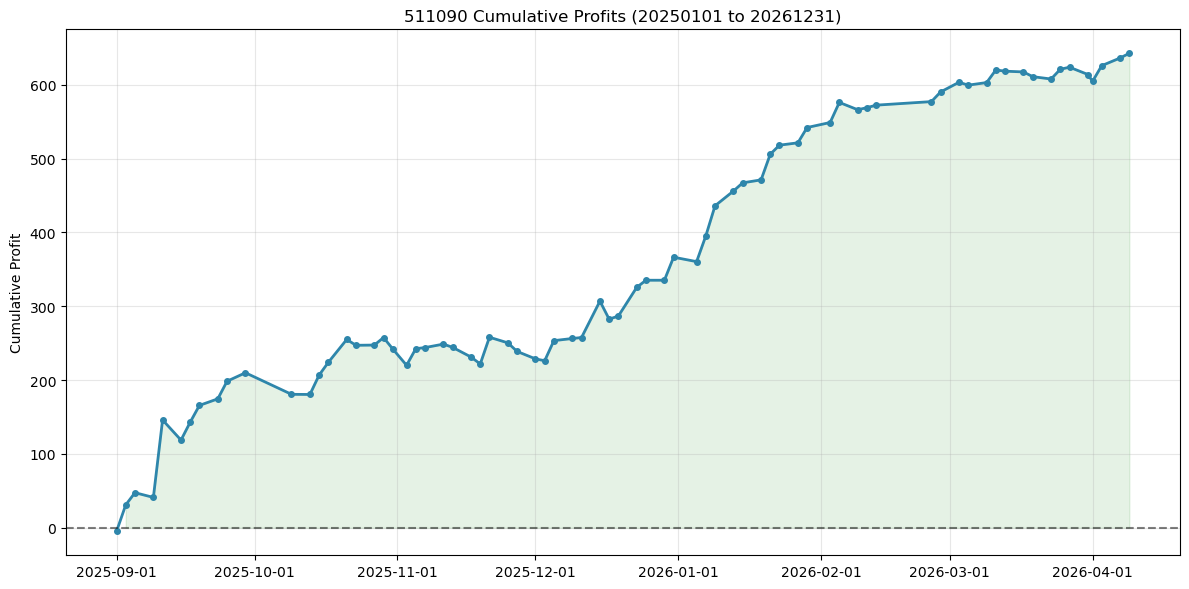


并行回测结果汇总:


In [7]:
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from tools.multi_day_backtest import backtest_summary

result_df = run_parallel_backtest(
    instrument_id=instrument_id,
    start_ymd="20250101",
    end_ymd="20261231",
    StrategyClass=strategy.StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4
)


print("\n并行回测结果汇总:")
summary = backtest_summary(result_df)

In [8]:
print(summary)

{'测试天数': 74, '累计总盈亏': np.float64(642.7), '总成交次数': 1680, '盈利交易次数': 662, '亏损交易次数': 1018, '加权每手胜率%': np.float64(39.4), '日均盈亏': np.float64(8.69), '胜率(天)%': 64.86, '盈亏比(日均)': np.float64(1.87), '最大单日盈利': 104.9, '最大单日亏损': -29.2, '每笔交易平均盈利': np.float64(0.38), '加权平均持仓时间(快照)': np.float64(345.99)}
